# Sales Performance Analysis

### 3Skill Internship – Project 1

**Objective:**  
Analyze sales performance to understand monthly revenue trends, 
top-performing products, sales patterns, and strong and weak 
performance areas.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Analysis Areas
- Monthly Revenue Analysis
- Sales Trends
- Top-Performing Products
- Category Performance
- Regional Performance
- Salesperson Performance
- Strong & Weak Performance Areas
- Business Insights

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Sales_Performance_Dataset.xlsx",sheet_name = "Sales_Raw")
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Salesperson,Sales_Channel,Payment_Method,Quantity,Unit_Price,Discount_Pct,Discount_Amount,Revenue,Cost,Profit,Order_Status,City
0,ORD100000,2026-08-29,CUST11759,Office Chair,Furniture,North,Salesperson_11,Online,Net Banking,1,8157.34,15.0,1223.60,6933.74,5042.78,1890.96,Delivered,Thane
1,ORD100001,2026-05-07,CUST11690,Laptop,Electronics,North,Salesperson_9,Retail Store,Debit Card,1,59735.74,15.0,8960.36,50775.38,41097.87,9677.51,Delivered,Hyderabad
2,ORD100002,2025-08-17,CUST10875,Desk,Furniture,South,Salesperson_6,Retail Store,Credit Card,4,10850.04,5.0,2170.01,41230.15,27132.70,14097.45,Delivered,Mumbai
3,ORD100003,2026-07-29,CUST11421,Keyboard,Accessories,North,Salesperson_3,Partner,Credit Card,1,1808.22,20.0,361.64,1446.58,1082.93,363.65,Delivered,Delhi
4,ORD100004,2026-06-21,CUST10466,Keyboard,Accessories,North,Salesperson_12,Online,Debit Card,2,1769.22,5.0,176.92,3361.52,2410.44,951.08,Delivered,Navi Mumbai


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12025
Columns: 18


In [6]:
print(df.shape)
print(df.info())

(12025, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12025 entries, 0 to 12024
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         12025 non-null  object        
 1   Order_Date       12025 non-null  datetime64[ns]
 2   Customer_ID      12025 non-null  object        
 3   Product          12025 non-null  object        
 4   Category         12025 non-null  object        
 5   Region           12025 non-null  object        
 6   Salesperson      11881 non-null  object        
 7   Sales_Channel    12025 non-null  object        
 8   Payment_Method   11905 non-null  object        
 9   Quantity         12025 non-null  int64         
 10  Unit_Price       12025 non-null  float64       
 11  Discount_Pct     11929 non-null  float64       
 12  Discount_Amount  12025 non-null  float64       
 13  Revenue          12025 non-null  float64       
 14  Cost             12025 non

In [7]:
df['Month'] = df['Order_Date'].dt.to_period("M").astype(str)
df[['Order_Date','Month']].head()

,Order_Date,Month
0,2026-08-29,2026-08
1,2026-05-07,2026-05
2,2025-08-17,2025-08
3,2026-07-29,2026-07
4,2026-06-21,2026-06


In [8]:
monthly_revenue = (
    df.groupby("Month")['Revenue'].sum().reset_index())
monthly_revenue

,Month,Revenue
0,2025-01,16564732.53
1,2025-02,13708054.11
2,2025-03,15796288.66
3,2025-04,14061059.58
4,2025-05,13369724.07
5,2025-06,14305428.40
6,2025-07,13585325.66
7,2025-08,16815805.47
8,2025-09,15297767.23
9,2025-10,14347541.89


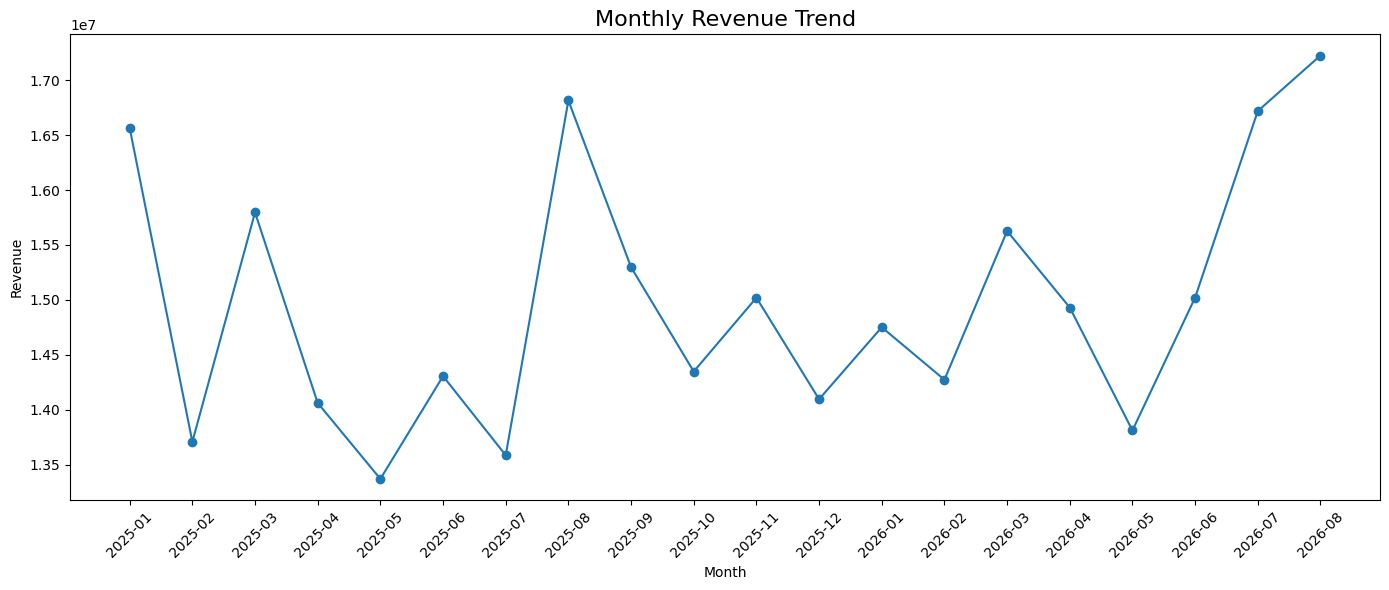

In [11]:
#Monthly Revenue Chart
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

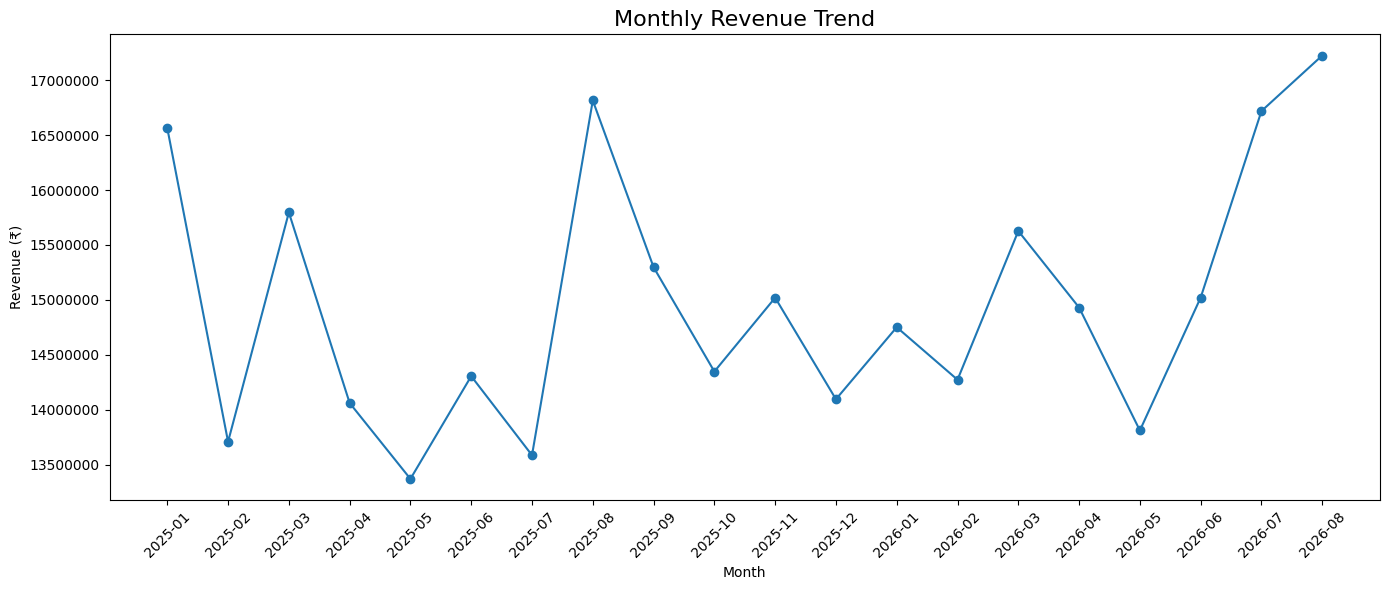

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [13]:
# Highest & Lowest Revenue Month

highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
Month          2026-08
Revenue    17225543.59
Name: 19, dtype: object

Lowest Revenue Month:
Month          2025-05
Revenue    13369724.07
Name: 4, dtype: object


In [14]:
#Average Monthly Revenue

average_monthly_revenue = monthly_revenue["Revenue"].mean()

print(
    f"Average Monthly Revenue: ₹{average_monthly_revenue:,.2f}"
)

Average Monthly Revenue: ₹14,966,279.39


In [15]:
#Monthly Revenue Growth

monthly_revenue["Revenue_Growth_%"] = (
    monthly_revenue["Revenue"].pct_change() * 100
)

monthly_revenue

,Month,Revenue,Revenue_Growth_%
0,2025-01,16564732.53,NaN
1,2025-02,13708054.11,-17.245545
2,2025-03,15796288.66,15.233632
3,2025-04,14061059.58,-10.985043
4,2025-05,13369724.07,-4.916667
5,2025-06,14305428.40,6.998681
6,2025-07,13585325.66,-5.033773
7,2025-08,16815805.47,23.779186
8,2025-09,15297767.23,-9.027449
9,2025-10,14347541.89,-6.211530


### Monthly Revenue Insights

- Monthly revenue was analyzed to identify overall sales trends.
- Revenue fluctuations were observed across different months.
- The highest and lowest revenue months were identified based on total monthly revenue.
- Month-over-month revenue growth was calculated to understand changes in sales performance.

In [16]:
#Product-wise Revenue

product_revenue = (
    df.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

product_revenue

,Product,Revenue
0,Laptop,91615275.27
1,Smartphone,45149217.85
2,Tablet,35363669.11
3,Monitor,24740596.13
4,Printer,19404684.81
5,Desk,19168833.68
6,Office Chair,14018879.22
7,External SSD,13555593.26
8,Smartwatch,11976751.27
9,Router,6861834.46


In [17]:
# Top 10 Products

top_10_products = product_revenue.head(10)

top_10_products

,Product,Revenue
0,Laptop,91615275.27
1,Smartphone,45149217.85
2,Tablet,35363669.11
3,Monitor,24740596.13
4,Printer,19404684.81
5,Desk,19168833.68
6,Office Chair,14018879.22
7,External SSD,13555593.26
8,Smartwatch,11976751.27
9,Router,6861834.46


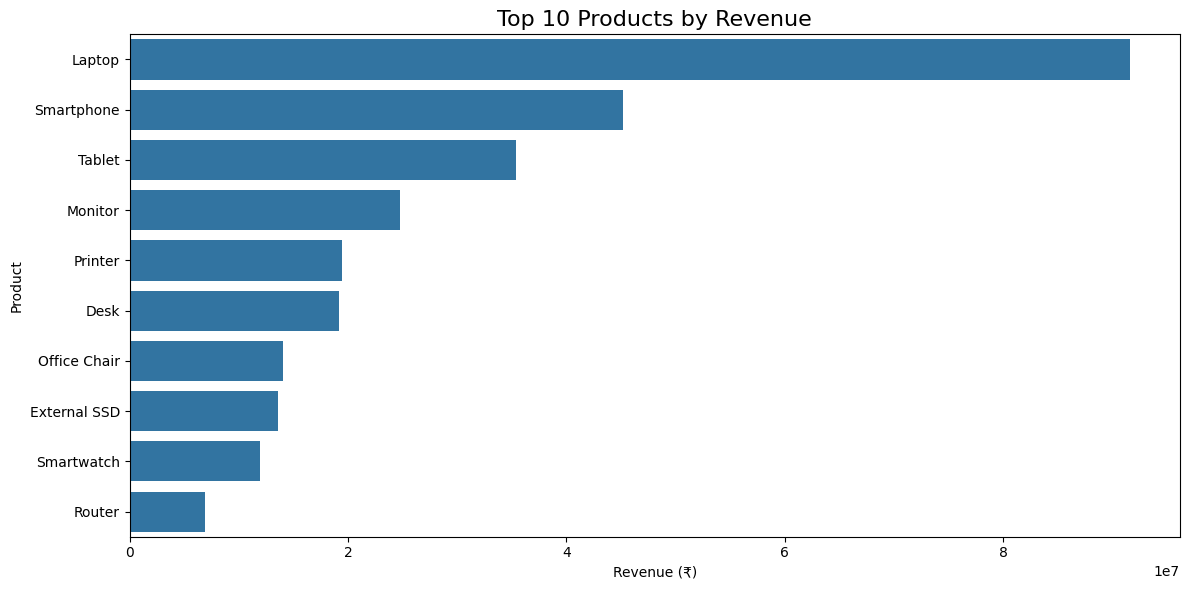

In [20]:
# Top 10 Products Chart

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_products,
    x="Revenue",
    y="Product"
)

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [21]:
# Best Performing Product
best_product = product_revenue.iloc[0]

print("Best Performing Product:")
print("Product:", best_product["Product"])
print(f"Revenue: ₹{best_product['Revenue']:,.2f}")

Best Performing Product:
Product: Laptop
Revenue: ₹91,615,275.27


In [22]:
# Top Product ka Revenue Share
total_revenue = df["Revenue"].sum()

top_10_revenue = top_10_products["Revenue"].sum()

top_10_share = (top_10_revenue / total_revenue) * 100

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Top 10 Products Revenue: ₹{top_10_revenue:,.2f}")
print(f"Top 10 Revenue Share: {top_10_share:.2f}%")

Total Revenue: ₹299,325,587.88
Top 10 Products Revenue: ₹281,855,335.06
Top 10 Revenue Share: 94.16%


In [23]:
# Product-wise Quantity

product_quantity = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

product_quantity.head(10)

,Product,Quantity
0,Power Bank,1911
1,Smartwatch,1887
2,Backpack,1883
3,Headphones,1876
4,Laptop,1833
5,Keyboard,1809
6,Tablet,1799
7,Router,1796
8,Smartphone,1777
9,External SSD,1769


In [24]:
# Revenue vs Quantity

product_performance = (
    df.groupby("Product")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Profit=("Profit", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)

product_performance.head(10)

,Product,Total_Quantity,Total_Revenue,Total_Profit,Orders
0,Laptop,1833,91615275.27,23479920.17,790
1,Smartphone,1777,45149217.85,11629787.99,778
2,Tablet,1799,35363669.11,9179253.39,807
3,Monitor,1716,24740596.13,6506884.08,764
4,Printer,1712,19404684.81,5080521.62,782
5,Desk,1765,19168833.68,5011657.13,767
6,Office Chair,1729,14018879.22,3586951.09,760
7,External SSD,1769,13555593.26,3616623.76,778
8,Smartwatch,1887,11976751.27,3156905.14,852
9,Router,1796,6861834.46,1811082.61,800


### Top-Performing Products Insights

- Products were ranked based on total revenue generated.
- The top 10 products were identified for performance comparison.
- Product quantity, revenue, profit, and number of orders were analyzed.
- The revenue contribution of the top 10 products was calculated.
- The analysis helps identify products that contribute significantly to overall sales performance.

In [25]:
# Category-wise Revenue
category_revenue = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue

,Category,Revenue
0,Electronics,1.968688e+08
1,Furniture,3.318771e+07
2,Accessories,2.568210e+07
3,Office,1.940468e+07
4,Storage,1.355559e+07
5,Networking,6.861834e+06
6,Lifestyle,3.764906e+06


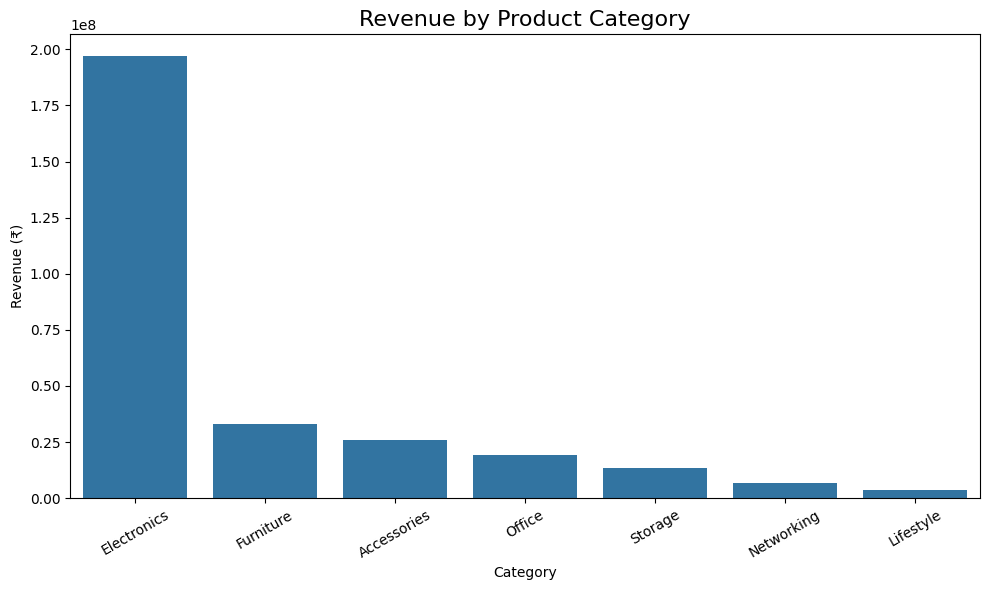

In [26]:
# Category Revenue Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    x="Category",
    y="Revenue"
)

plt.title("Revenue by Product Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [27]:
# Category-wise Profit

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_profit

,Category,Profit
0,Electronics,50795845.63
1,Furniture,8598608.22
2,Accessories,6708217.87
3,Office,5080521.62
4,Storage,3616623.76
5,Networking,1811082.61
6,Lifestyle,992906.01


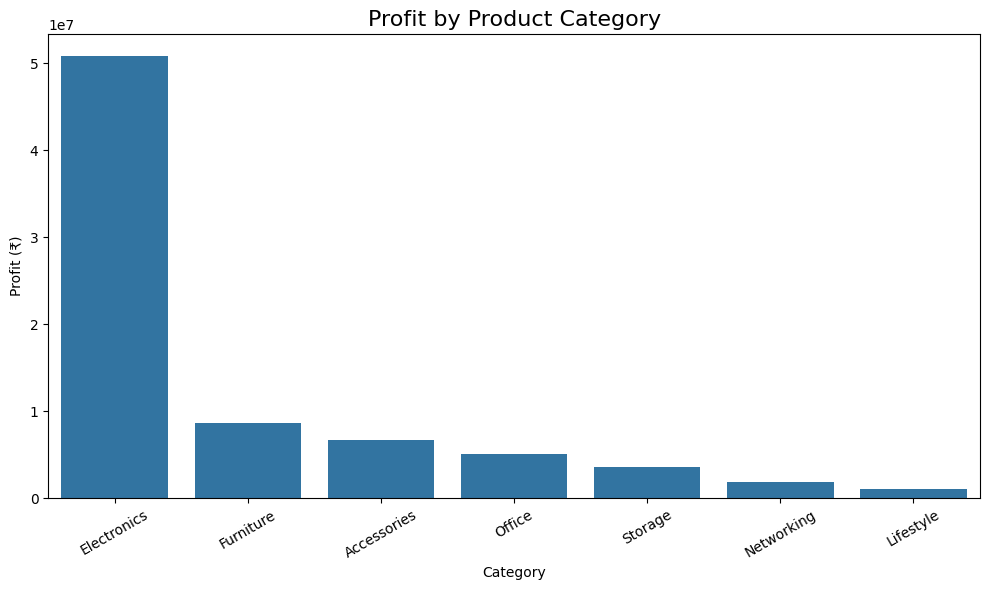

In [28]:
# Profit Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_profit,
    x="Category",
    y="Profit"
)

plt.title("Profit by Product Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [29]:
# Category Performance Table

category_performance = (
    df.groupby("Category")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Cost=("Cost", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)

category_performance

,Category,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit
0,Electronics,3139,7125,1.968688e+08,1.460729e+08,50795845.63
1,Furniture,1527,3494,3.318771e+07,2.458910e+07,8598608.22
2,Accessories,4134,9215,2.568210e+07,1.897388e+07,6708217.87
3,Office,782,1712,1.940468e+07,1.432416e+07,5080521.62
4,Storage,778,1769,1.355559e+07,9.938970e+06,3616623.76
5,Networking,800,1796,6.861834e+06,5.050752e+06,1811082.61
6,Lifestyle,840,1883,3.764906e+06,2.772000e+06,992906.01


In [30]:
# Category Revenue Share

category_performance["Revenue_Share_%"] = (
    category_performance["Total_Revenue"] /
    category_performance["Total_Revenue"].sum()
) * 100

category_performance

,Category,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit,Revenue_Share_%
0,Electronics,3139,7125,1.968688e+08,1.460729e+08,50795845.63,65.770775
1,Furniture,1527,3494,3.318771e+07,2.458910e+07,8598608.22,11.087496
2,Accessories,4134,9215,2.568210e+07,1.897388e+07,6708217.87,8.579988
3,Office,782,1712,1.940468e+07,1.432416e+07,5080521.62,6.482802
4,Storage,778,1769,1.355559e+07,9.938970e+06,3616623.76,4.528712
5,Networking,800,1796,6.861834e+06,5.050752e+06,1811082.61,2.292432
6,Lifestyle,840,1883,3.764906e+06,2.772000e+06,992906.01,1.257796


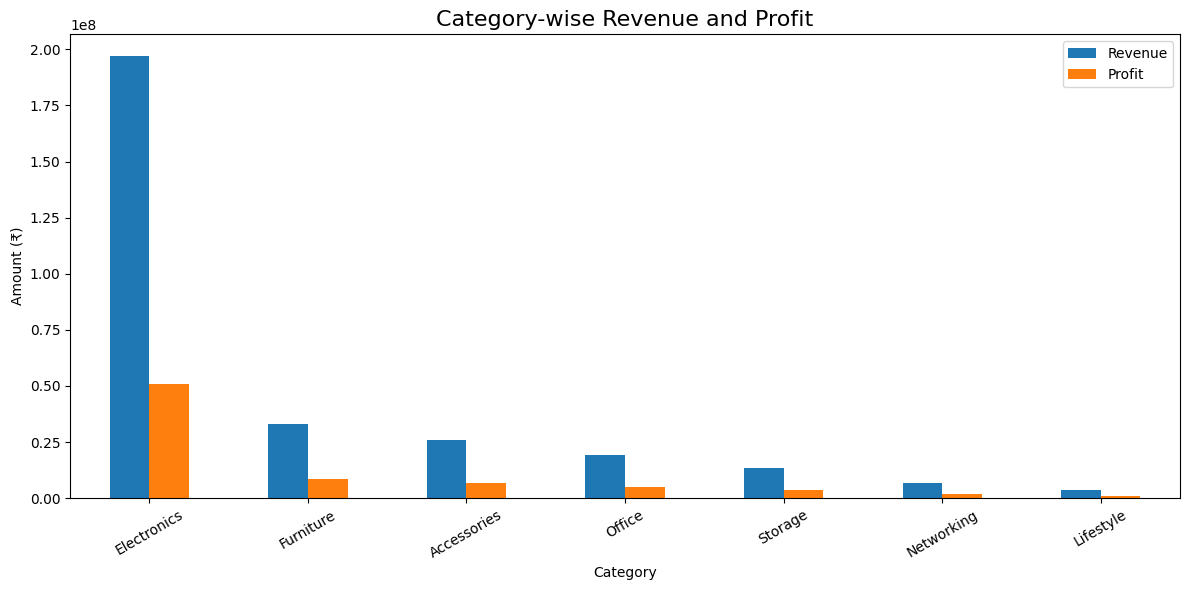

In [31]:
# Category Performance Visualization

category_plot = category_performance.set_index("Category")[
    ["Total_Revenue", "Total_Profit"]
]

category_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Category-wise Revenue and Profit", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=30)
plt.legend(["Revenue", "Profit"])

plt.tight_layout()
plt.show()

### Category Performance Insights

- Revenue and profit were analyzed across different product categories.
- Category-wise order volume and quantity were compared with revenue.
- Profit margin was calculated to evaluate the profitability of each category.
- Revenue share was calculated to understand each category's contribution to overall sales.
- The analysis helps identify categories with strong revenue contribution and categories requiring further attention.

In [32]:
# Region-wise Revenue
region_revenue = (
    df.groupby("Region")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_revenue

,Region,Revenue
0,West,76190191.59
1,North,75794688.87
2,South,75319565.36
3,East,72021142.06


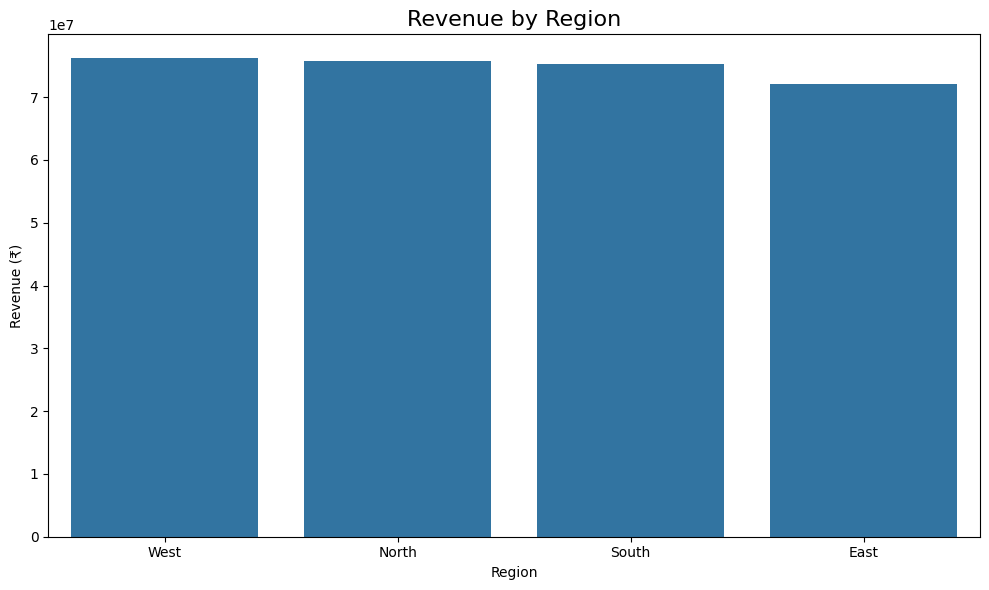

In [33]:
# Region Revenue Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_revenue,
    x="Region",
    y="Revenue"
)

plt.title("Revenue by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

In [34]:
# Region Performance Table

region_performance = (
    df.groupby("Region")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Cost=("Cost", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)

region_performance

,Region,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit
0,West,3044,6757,76190191.59,56424040.22,19766151.37
1,North,3032,6860,75794688.87,56284888.99,19509799.88
2,South,2934,6654,75319565.36,55586282.70,19733282.66
3,East,2990,6723,72021142.06,53426570.25,18594571.81


In [35]:
# Profit Margin by Region
region_performance["Profit_Margin_%"] = (
    region_performance["Total_Profit"] /
    region_performance["Total_Revenue"]
) * 100

region_performance

,Region,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit,Profit_Margin_%
0,West,3044,6757,76190191.59,56424040.22,19766151.37,25.943171
1,North,3032,6860,75794688.87,56284888.99,19509799.88,25.740326
2,South,2934,6654,75319565.36,55586282.70,19733282.66,26.199411
3,East,2990,6723,72021142.06,53426570.25,18594571.81,25.818213


In [36]:
# Revenue Share by Region
region_performance["Revenue_Share_%"] = (
    region_performance["Total_Revenue"] /
    region_performance["Total_Revenue"].sum()
) * 100

region_performance

,Region,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit,Profit_Margin_%,Revenue_Share_%
0,West,3044,6757,76190191.59,56424040.22,19766151.37,25.943171,25.453952
1,North,3032,6860,75794688.87,56284888.99,19509799.88,25.740326,25.321821
2,South,2934,6654,75319565.36,55586282.70,19733282.66,26.199411,25.163089
3,East,2990,6723,72021142.06,53426570.25,18594571.81,25.818213,24.061138


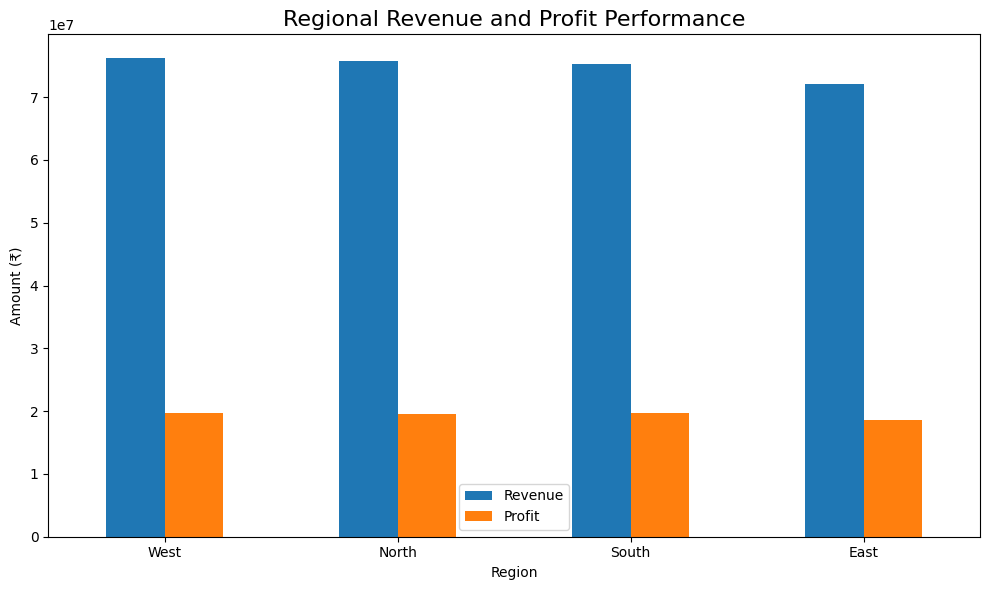

In [37]:
# Revenue vs Profit
region_plot = region_performance.set_index("Region")[
    ["Total_Revenue", "Total_Profit"]
]

region_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regional Revenue and Profit Performance", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)
plt.legend(["Revenue", "Profit"])

plt.tight_layout()
plt.show()

In [38]:
# Strong & Weak Regions

strong_region = region_performance.loc[
    region_performance["Total_Revenue"].idxmax()
]

weak_region = region_performance.loc[
    region_performance["Total_Revenue"].idxmin()
]

print("Highest Revenue Region:")
print(strong_region)

print("\nLowest Revenue Region:")
print(weak_region)

Highest Revenue Region:
Region                    West
Total_Orders              3044
Total_Quantity            6757
Total_Revenue      76190191.59
Total_Cost         56424040.22
Total_Profit       19766151.37
Profit_Margin_%      25.943171
Revenue_Share_%      25.453952
Name: 0, dtype: object

Lowest Revenue Region:
Region                    East
Total_Orders              2990
Total_Quantity            6723
Total_Revenue      72021142.06
Total_Cost         53426570.25
Total_Profit       18594571.81
Profit_Margin_%      25.818213
Revenue_Share_%      24.061138
Name: 3, dtype: object


### Regional Performance Insights

- Regional sales performance was analyzed using revenue, orders, quantity, cost, and profit.
- Revenue contribution of each region was calculated.
- Profit margin was used to evaluate regional profitability.
- Regions with higher and lower revenue contributions were identified.
- The comparison helps identify strong and weak areas for further business analysis.

In [39]:
# Channel-wise Revenue
channel_revenue = (
    df.groupby("Sales_Channel")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

channel_revenue

,Sales_Channel,Revenue
0,Retail Store,99948372.59
1,Partner,99828460.57
2,Online,99548754.72


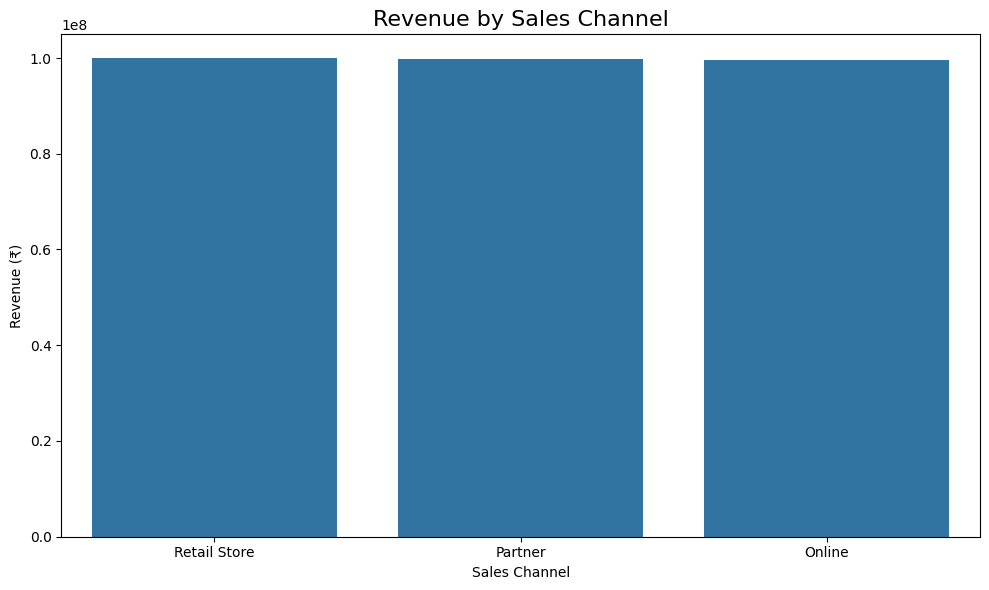

In [40]:
# Sales Channel Revenue Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_revenue,
    x="Sales_Channel",
    y="Revenue"
)

plt.title("Revenue by Sales Channel", fontsize=16)
plt.xlabel("Sales Channel")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

In [41]:
# Complete Channel Performance
channel_performance = (
    df.groupby("Sales_Channel")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Cost=("Cost", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)

channel_performance

,Sales_Channel,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit
0,Retail Store,3996,8998,99948372.59,73991821.00,25956551.59
1,Partner,3928,8855,99828460.57,73705111.05,26123349.52
2,Online,4076,9141,99548754.72,74024850.11,25523904.61


In [42]:
# Profit Margin

channel_performance["Profit_Margin_%"] = (
    channel_performance["Total_Profit"] /
    channel_performance["Total_Revenue"]
) * 100

channel_performance

,Sales_Channel,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit,Profit_Margin_%
0,Retail Store,3996,8998,99948372.59,73991821.00,25956551.59,25.969959
1,Partner,3928,8855,99828460.57,73705111.05,26123349.52,26.168238
2,Online,4076,9141,99548754.72,74024850.11,25523904.61,25.639602


In [43]:
# Revenue Share
channel_performance["Revenue_Share_%"] = (
    channel_performance["Total_Revenue"] /
    channel_performance["Total_Revenue"].sum()
) * 100

channel_performance

,Sales_Channel,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit,Profit_Margin_%,Revenue_Share_%
0,Retail Store,3996,8998,99948372.59,73991821.00,25956551.59,25.969959,33.391189
1,Partner,3928,8855,99828460.57,73705111.05,26123349.52,26.168238,33.351128
2,Online,4076,9141,99548754.72,74024850.11,25523904.61,25.639602,33.257683


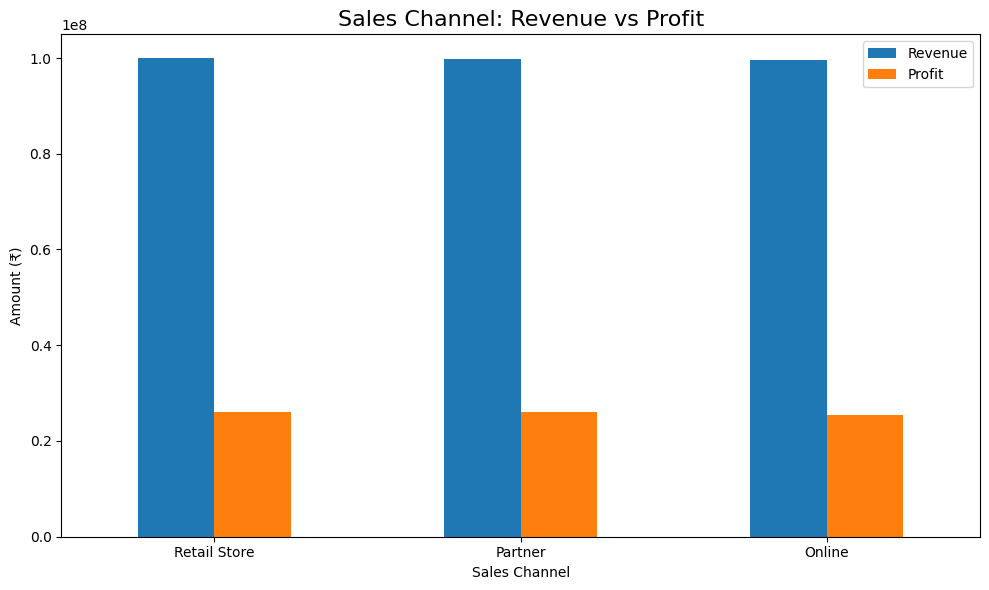

In [44]:
# Revenue vs Profit Chart
channel_plot = channel_performance.set_index("Sales_Channel")[
    ["Total_Revenue", "Total_Profit"]
]

channel_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales Channel: Revenue vs Profit", fontsize=16)
plt.xlabel("Sales Channel")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)
plt.legend(["Revenue", "Profit"])

plt.tight_layout()
plt.show()

In [45]:
#Best Performing Channel

best_channel = channel_performance.loc[
    channel_performance["Total_Revenue"].idxmax()
]

print("Highest Revenue Sales Channel:")
print("Channel:", best_channel["Sales_Channel"])
print(f"Revenue: ₹{best_channel['Total_Revenue']:,.2f}")
print(f"Profit: ₹{best_channel['Total_Profit']:,.2f}")
print(f"Profit Margin: {best_channel['Profit_Margin_%']:.2f}%")

Highest Revenue Sales Channel:
Channel: Retail Store
Revenue: ₹99,948,372.59
Profit: ₹25,956,551.59
Profit Margin: 25.97%


### Sales Channel Insights

- Sales performance was analyzed across Online, Retail Store, and Partner channels.
- Revenue, orders, quantity, cost, and profit were compared across channels.
- Revenue share and profit margin were calculated for each sales channel.
- The analysis helps understand which channels contribute significantly to overall sales performance.
- Channel-level performance can support future decisions related to sales strategy and resource allocation.

In [46]:
# Salesperson-wise Revenue
salesperson_revenue = (
    df.groupby("Salesperson")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

salesperson_revenue

,Salesperson,Revenue
0,Salesperson_13,21852031.18
1,Salesperson_7,21446593.70
2,Salesperson_8,21110319.01
3,Salesperson_14,20887795.12
4,Salesperson_2,20293774.20
5,Salesperson_4,20116864.63
6,Salesperson_10,19807379.15
7,Salesperson_5,19545405.11
8,Salesperson_11,19397959.69
9,Salesperson_3,19385613.53


In [47]:
# Top 10 Salespersons
top_salespersons = salesperson_revenue.head(10)

top_salespersons

,Salesperson,Revenue
0,Salesperson_13,21852031.18
1,Salesperson_7,21446593.70
2,Salesperson_8,21110319.01
3,Salesperson_14,20887795.12
4,Salesperson_2,20293774.20
5,Salesperson_4,20116864.63
6,Salesperson_10,19807379.15
7,Salesperson_5,19545405.11
8,Salesperson_11,19397959.69
9,Salesperson_3,19385613.53


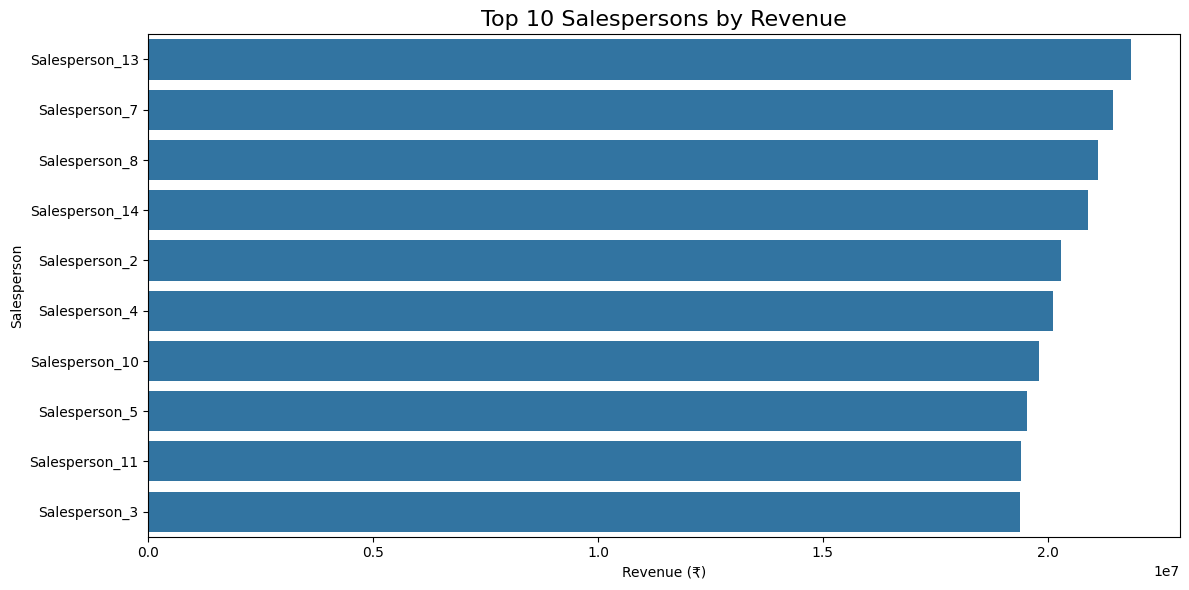

In [48]:
# Top 10 Salespersons Chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_salespersons,
    x="Revenue",
    y="Salesperson"
)

plt.title("Top 10 Salespersons by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)")
plt.ylabel("Salesperson")

plt.tight_layout()
plt.show()

In [49]:
# Complete Salesperson Performance

salesperson_performance = (
    df.groupby("Salesperson")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Cost=("Cost", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)

salesperson_performance

,Salesperson,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit
0,Salesperson_13,825,1806,21852031.18,16281321.92,5570709.26
1,Salesperson_7,794,1807,21446593.70,15990893.64,5455700.06
2,Salesperson_8,825,1885,21110319.01,15540826.56,5569492.45
3,Salesperson_14,844,1892,20887795.12,15497355.53,5390439.59
4,Salesperson_2,798,1763,20293774.20,14957966.77,5335807.43
5,Salesperson_4,797,1783,20116864.63,14822872.66,5293991.97
6,Salesperson_10,801,1768,19807379.15,14663758.30,5143620.85
7,Salesperson_5,821,1846,19545405.11,14489564.75,5055840.36
8,Salesperson_11,798,1820,19397959.69,14226615.94,5171343.75
9,Salesperson_3,771,1767,19385613.53,14445598.50,4940015.03


In [50]:
# Top 5 Salespersons by Profit

top_profit_salespersons = (
    salesperson_performance
    .sort_values("Total_Profit", ascending=False)
    .head(5)
)

top_profit_salespersons

,Salesperson,Total_Orders,Total_Quantity,Total_Revenue,Total_Cost,Total_Profit
0,Salesperson_13,825,1806,21852031.18,16281321.92,5570709.26
2,Salesperson_8,825,1885,21110319.01,15540826.56,5569492.45
1,Salesperson_7,794,1807,21446593.70,15990893.64,5455700.06
3,Salesperson_14,844,1892,20887795.12,15497355.53,5390439.59
4,Salesperson_2,798,1763,20293774.20,14957966.77,5335807.43


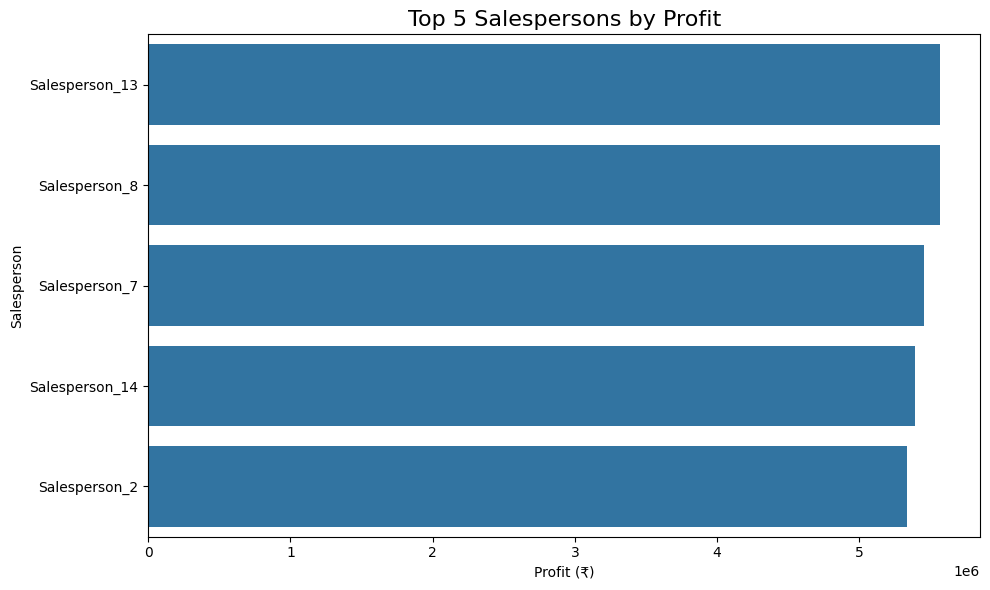

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_profit_salespersons,
    x="Total_Profit",
    y="Salesperson"
)

plt.title("Top 5 Salespersons by Profit", fontsize=16)
plt.xlabel("Profit (₹)")
plt.ylabel("Salesperson")

plt.tight_layout()
plt.show()

In [52]:
# Highest & Lowest Revenue Salesperson
highest_salesperson = salesperson_performance.iloc[0]

lowest_salesperson = salesperson_performance.iloc[-1]

print("Highest Revenue Salesperson:")
print(highest_salesperson)

print("\nLowest Revenue Salesperson:")
print(lowest_salesperson)

Highest Revenue Salesperson:
Salesperson       Salesperson_13
Total_Orders                 825
Total_Quantity              1806
Total_Revenue        21852031.18
Total_Cost           16281321.92
Total_Profit          5570709.26
Name: 0, dtype: object

Lowest Revenue Salesperson:
Salesperson       Salesperson_1
Total_Orders                745
Total_Quantity             1656
Total_Revenue       18096877.86
Total_Cost          13388241.86
Total_Profit          4708636.0
Name: 14, dtype: object


### Salesperson Performance Insights

- Salespersons were compared based on revenue, orders, quantity, and profit.
- The top-performing salespersons were identified based on revenue generation.
- Profit performance was also analyzed to distinguish revenue performance from profitability.
- Differences in salesperson performance highlight areas for further investigation and performance improvement.

In [53]:
# Overall KPIs
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = total_revenue / total_orders

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

Total Revenue: ₹299,325,587.88
Total Profit: ₹77,603,805.72
Total Orders: 12,000
Total Quantity Sold: 26,994
Average Order Value: ₹24,943.80


In [54]:
# Overall Profit Margin
overall_profit_margin = (total_profit / total_revenue) * 100

print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

Overall Profit Margin: 25.93%


In [55]:
# Strong & Weak Product Areas

product_performance = (
    df.groupby("Product")
      .agg(
          Orders=("Order_ID", "nunique"),
          Quantity=("Quantity", "sum"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

product_performance["Profit_Margin_%"] = (
    product_performance["Profit"] /
    product_performance["Revenue"]
) * 100

product_performance = product_performance.sort_values(
    "Revenue", ascending=False
)

product_performance

,Product,Orders,Quantity,Revenue,Profit,Profit_Margin_%
5,Laptop,790,1833,91615275.27,23479920.17,25.628827
12,Smartphone,778,1777,45149217.85,11629787.99,25.758559
14,Tablet,807,1799,35363669.11,9179253.39,25.956734
6,Monitor,764,1716,24740596.13,6506884.08,26.300434
10,Printer,782,1712,19404684.81,5080521.62,26.181933
1,Desk,767,1765,19168833.68,5011657.13,26.144820
8,Office Chair,760,1729,14018879.22,3586951.09,25.586575
2,External SSD,778,1769,13555593.26,3616623.76,26.679937
13,Smartwatch,852,1887,11976751.27,3156905.14,26.358610
11,Router,800,1796,6861834.46,1811082.61,26.393563


In [56]:
# Strong & Weak Categories
category_performance = (
    df.groupby("Category")
      .agg(
          Orders=("Order_ID", "nunique"),
          Quantity=("Quantity", "sum"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

category_performance["Profit_Margin_%"] = (
    category_performance["Profit"] /
    category_performance["Revenue"]
) * 100

category_performance.sort_values(
    "Revenue", ascending=False
)

,Category,Orders,Quantity,Revenue,Profit,Profit_Margin_%
1,Electronics,3139,7125,1.968688e+08,50795845.63,25.801882
2,Furniture,1527,3494,3.318771e+07,8598608.22,25.909011
0,Accessories,4134,9215,2.568210e+07,6708217.87,26.120210
5,Office,782,1712,1.940468e+07,5080521.62,26.181933
6,Storage,778,1769,1.355559e+07,3616623.76,26.679937
4,Networking,800,1796,6.861834e+06,1811082.61,26.393563
3,Lifestyle,840,1883,3.764906e+06,992906.01,26.372665


In [57]:
# Highest revenue category:
category_performance.loc[
    category_performance["Revenue"].idxmax()
]
#Lowest revenue category:
category_performance.loc[
    category_performance["Revenue"].idxmin()
]

Category            Lifestyle
Orders                    840
Quantity                 1883
Revenue            3764905.88
Profit              992906.01
Profit_Margin_%     26.372665
Name: 3, dtype: object

In [58]:
# Strong & Weak Regions
region_performance = (
    df.groupby("Region")
      .agg(
          Orders=("Order_ID", "nunique"),
          Quantity=("Quantity", "sum"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

region_performance["Profit_Margin_%"] = (
    region_performance["Profit"] /
    region_performance["Revenue"]
) * 100

region_performance.sort_values(
    "Revenue", ascending=False
)

,Region,Orders,Quantity,Revenue,Profit,Profit_Margin_%
3,West,3044,6757,76190191.59,19766151.37,25.943171
1,North,3032,6860,75794688.87,19509799.88,25.740326
2,South,2934,6654,75319565.36,19733282.66,26.199411
0,East,2990,6723,72021142.06,18594571.81,25.818213


In [59]:
# Strong & Weak Sales Channels
channel_performance = (
    df.groupby("Sales_Channel")
      .agg(
          Orders=("Order_ID", "nunique"),
          Quantity=("Quantity", "sum"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

channel_performance["Profit_Margin_%"] = (
    channel_performance["Profit"] /
    channel_performance["Revenue"]
) * 100

channel_performance.sort_values(
    "Revenue", ascending=False
)

,Sales_Channel,Orders,Quantity,Revenue,Profit,Profit_Margin_%
2,Retail Store,3996,8998,99948372.59,25956551.59,25.969959
1,Partner,3928,8855,99828460.57,26123349.52,26.168238
0,Online,4076,9141,99548754.72,25523904.61,25.639602


In [60]:
# Overall Performance Summary

performance_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value",
        "Overall Profit Margin"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_orders,
        total_quantity,
        average_order_value,
        overall_profit_margin
    ]
})

performance_summary

,Metric,Value
0,Total Revenue,2.993256e+08
1,Total Profit,7.760381e+07
2,Total Orders,1.200000e+04
3,Total Quantity Sold,2.699400e+04
4,Average Order Value,2.494380e+04
5,Overall Profit Margin,2.592622e+01


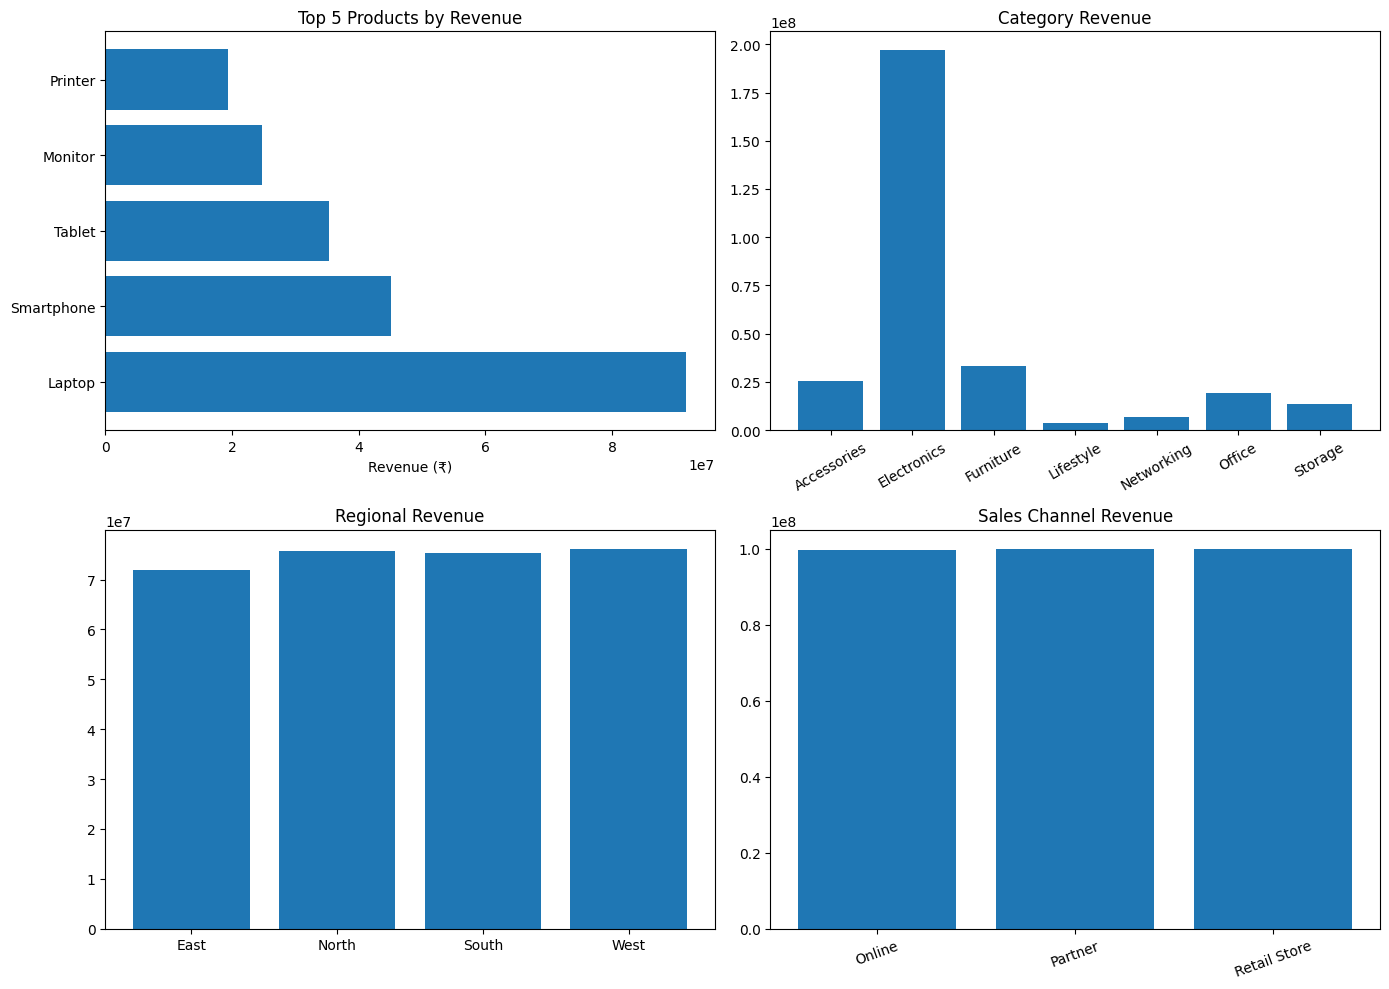

In [61]:
# Strong & Weak Areas Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Products
top_products = product_performance.head(5)

axes[0, 0].barh(
    top_products["Product"],
    top_products["Revenue"]
)
axes[0, 0].set_title("Top 5 Products by Revenue")
axes[0, 0].set_xlabel("Revenue (₹)")

# Categories
axes[0, 1].bar(
    category_performance["Category"],
    category_performance["Revenue"]
)
axes[0, 1].set_title("Category Revenue")
axes[0, 1].tick_params(axis="x", rotation=30)

# Regions
axes[1, 0].bar(
    region_performance["Region"],
    region_performance["Revenue"]
)
axes[1, 0].set_title("Regional Revenue")

# Channels
axes[1, 1].bar(
    channel_performance["Sales_Channel"],
    channel_performance["Revenue"]
)
axes[1, 1].set_title("Sales Channel Revenue")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Strong and Weak Performance Areas

The sales performance was evaluated across products, categories,
regions, and sales channels using revenue, profit, order volume,
and profit margin.

### Strong Performance Areas
- High-revenue products were identified using total revenue.
- Strong-performing categories were identified based on revenue contribution.
- Regional performance was compared using revenue and profitability.
- Sales channels were evaluated based on revenue and profit.

### Areas Requiring Attention
- Lower-revenue products and categories were identified for further analysis.
- Regions with comparatively lower revenue contribution were highlighted.
- Sales channels with lower revenue or profitability can be investigated further.
- Profit margin was considered alongside revenue to avoid evaluating performance using revenue alone.

In [62]:
# Final KPI Summary
final_kpis = {
    "Total Revenue": total_revenue,
    "Total Profit": total_profit,
    "Total Orders": total_orders,
    "Total Quantity Sold": total_quantity,
    "Average Order Value": average_order_value,
    "Overall Profit Margin": overall_profit_margin
}

for metric, value in final_kpis.items():
    if "Margin" in metric:
        print(f"{metric}: {value:.2f}%")
    elif "Orders" in metric or "Quantity" in metric:
        print(f"{metric}: {value:,.0f}")
    else:
        print(f"{metric}: ₹{value:,.2f}")

Total Revenue: ₹299,325,587.88
Total Profit: ₹77,603,805.72
Total Orders: 12,000
Total Quantity Sold: 26,994
Average Order Value: ₹24,943.80
Overall Profit Margin: 25.93%


In [63]:
# Automatically Generate Key Findings
best_product = product_performance.iloc[0]
lowest_product = product_performance.iloc[-1]

best_category = category_performance.loc[
    category_performance["Revenue"].idxmax()
]

lowest_category = category_performance.loc[
    category_performance["Revenue"].idxmin()
]

best_region = region_performance.loc[
    region_performance["Revenue"].idxmax()
]

lowest_region = region_performance.loc[
    region_performance["Revenue"].idxmin()
]

best_channel = channel_performance.loc[
    channel_performance["Revenue"].idxmax()
]

lowest_channel = channel_performance.loc[
    channel_performance["Revenue"].idxmin()
]

print("KEY BUSINESS FINDINGS")
print("-" * 60)

print(
    f"1. Total revenue generated was ₹{total_revenue:,.2f}, "
    f"with total profit of ₹{total_profit:,.2f}."
)

print(
    f"2. {best_product['Product']} was the highest-revenue product, "
    f"generating ₹{best_product['Revenue']:,.2f}."
)

print(
    f"3. {lowest_product['Product']} generated the lowest revenue "
    f"among the analyzed products, at ₹{lowest_product['Revenue']:,.2f}."
)

print(
    f"4. {best_category['Category']} was the highest-revenue category, "
    f"contributing ₹{best_category['Revenue']:,.2f}."
)

print(
    f"5. {best_region['Region']} generated the highest regional revenue, "
    f"at ₹{best_region['Revenue']:,.2f}."
)

print(
    f"6. {best_channel['Sales_Channel']} was the highest-revenue sales channel, "
    f"generating ₹{best_channel['Revenue']:,.2f}."
)

print(
    f"7. The overall profit margin was {overall_profit_margin:.2f}%."
)

KEY BUSINESS FINDINGS
------------------------------------------------------------
1. Total revenue generated was ₹299,325,587.88, with total profit of ₹77,603,805.72.
2. Laptop was the highest-revenue product, generating ₹91,615,275.27.
3. Mouse generated the lowest revenue among the analyzed products, at ₹1,715,406.94.
4. Electronics was the highest-revenue category, contributing ₹196,868,758.36.
5. West generated the highest regional revenue, at ₹76,190,191.59.
6. Retail Store was the highest-revenue sales channel, generating ₹99,948,372.59.
7. The overall profit margin was 25.93%.


In [64]:
# Highest & Lowest Revenue Month
highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print(
    f"Highest Revenue Month: "
    f"{highest_month['Month']} — ₹{highest_month['Revenue']:,.2f}"
)

print(
    f"Lowest Revenue Month: "
    f"{lowest_month['Month']} — ₹{lowest_month['Revenue']:,.2f}"
)

Highest Revenue Month: 2026-08 — ₹17,225,543.59
Lowest Revenue Month: 2025-05 — ₹13,369,724.07


In [66]:
# Top 3 Products
print("Top 3 Products by Revenue")

top_3 = product_performance.head(3)

for i, row in enumerate(top_3.itertuples(), start=1):
    print(
        f"{i}. {row.Product} — ₹{row.Revenue:,.2f}"
    )

Top 3 Products by Revenue
1. Laptop — ₹91,615,275.27
2. Smartphone — ₹45,149,217.85
3. Tablet — ₹35,363,669.11


# ## Key Business Insights

1. **Overall Sales Performance**  
   The business generated ₹[TOTAL REVENUE] in total revenue from
   [TOTAL ORDERS] orders, with an overall profit of ₹[TOTAL PROFIT].

2. **Monthly Sales Trend**  
   The highest monthly revenue was recorded in [MONTH], while
   [MONTH] recorded the lowest monthly revenue. This indicates
   variation in monthly sales performance.

3. **Top Product Performance**  
   [PRODUCT] was the highest-revenue product, generating
   ₹[REVENUE]. The top-performing products contributed significantly
   to overall sales.

4. **Category Performance**  
   [CATEGORY] generated the highest revenue among all product
   categories, while [CATEGORY] recorded the lowest revenue.

5. **Regional Performance**  
   [REGION] generated the highest regional revenue, whereas
   [REGION] had the lowest revenue contribution.

6. **Sales Channel Performance**  
   [CHANNEL] generated the highest revenue among the available
   sales channels.

7. **Profitability**  
   The overall profit margin was [MARGIN]%, indicating the relationship
   between sales revenue and profit generation.

8. **Performance Improvement Areas**  
   Lower-performing products, categories, regions, and channels can
   be further investigated to understand the reasons behind their
   comparatively lower contribution.

# # Conclusion

The Sales Performance Analysis provided a detailed view of sales
activity across products, categories, regions, sales channels, and
salespersons.

The analysis helped identify monthly revenue trends, top-performing
products, high-contributing categories and regions, and areas with
comparatively lower performance.

Key performance indicators such as total revenue, total profit,
total orders, quantity sold, average order value, and profit margin
were calculated to provide a comprehensive view of business
performance.

The findings can be used to support data-driven decisions related to
product performance, regional sales, sales channels, and future
business improvement opportunities.